
# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


## Import Libraries

In [1]:
# Import required libraries
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print('All libraries imported successfully!')

All libraries imported successfully!


## Load Dataset

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/main/labs/Lab-03_LR_SVC/Student_Performance.csv"
df = pd.read_csv(url)

print("First 5 rows of the dataset:")
display(df.head())

print("\nShape of dataset:", df.shape)
print("\nData types:")
display(df.dtypes)

First 5 rows of the dataset:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0



Shape of dataset: (10000, 6)

Data types:


,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


## Exploratory Data Analysis

In [3]:
# Check type, info, and summary statistics
print("Dataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all"))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB

Summary statistics:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,No,NaN,NaN,NaN
freq,NaN,NaN,5052,NaN,NaN,NaN
mean,4.992900,69.445700,NaN,6.530600,4.583300,55.224800
std,2.589309,17.343152,NaN,1.695863,2.867348,19.212558
min,1.000000,40.000000,NaN,4.000000,0.000000,10.000000
25%,3.000000,54.000000,NaN,5.000000,2.000000,40.000000
50%,5.000000,69.000000,NaN,7.000000,5.000000,55.000000
75%,7.000000,85.000000,NaN,8.000000,7.000000,71.000000


In [4]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
display(missing_values.to_frame(name="Missing Values"))

Missing values in each column:


,Missing Values
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [5]:
# Check duplicate values
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 127


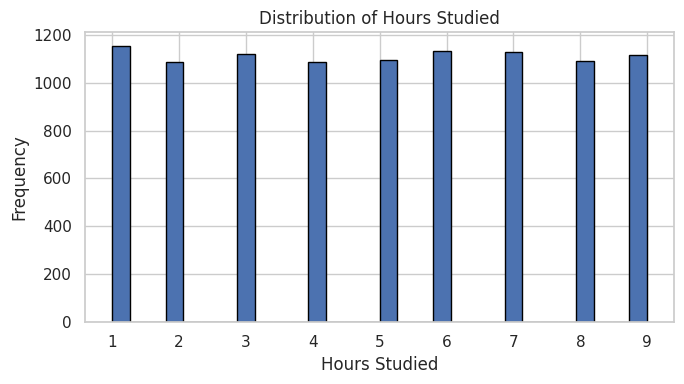

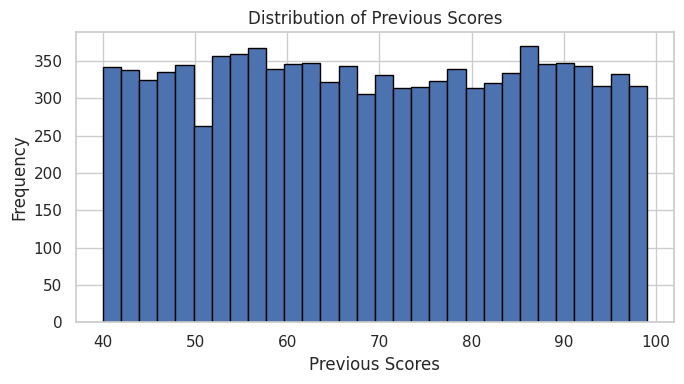

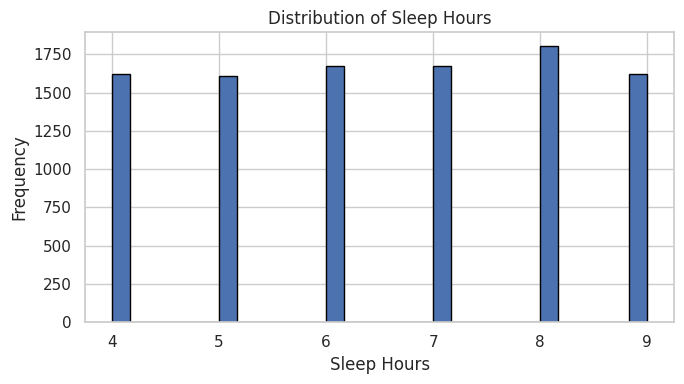

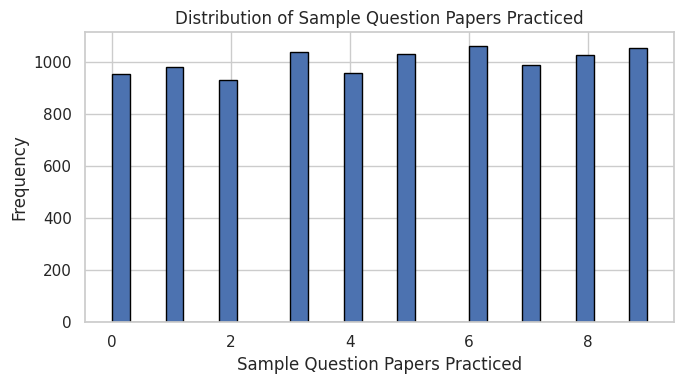

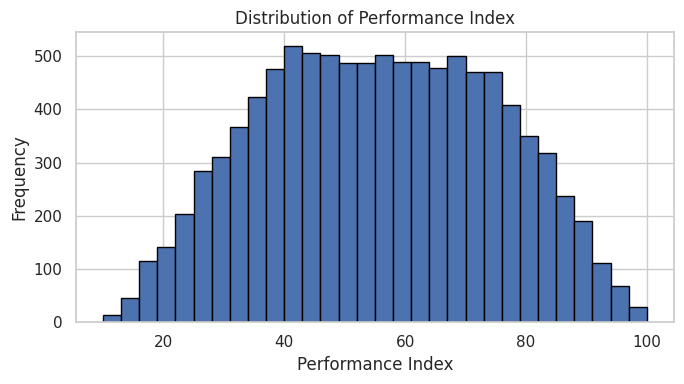

In [6]:
# Distribution plots
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column], bins=30, edgecolor="black")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Encoding

In [7]:
# Encode categorical columns if any
df_encoded = df.copy()

if "Extracurricular Activities" in df_encoded.columns:
    df_encoded["Extracurricular Activities"] = df_encoded["Extracurricular Activities"].map({"Yes": 1, "No": 0})

print("Encoded dataset preview:")
display(df_encoded.head())

print("\nUpdated data types after encoding:")
display(df_encoded.dtypes)

Encoded dataset preview:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0



Updated data types after encoding:


,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,int64
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


## Visualization

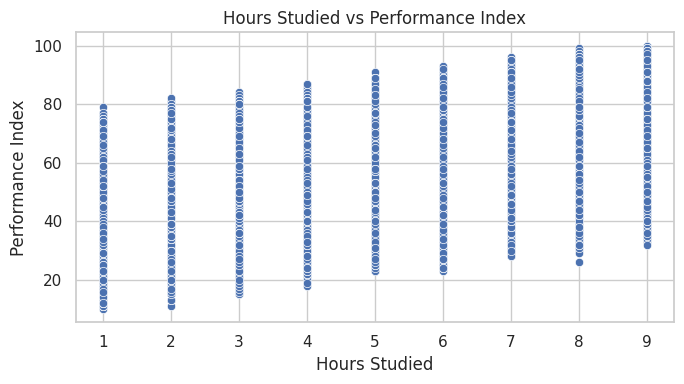

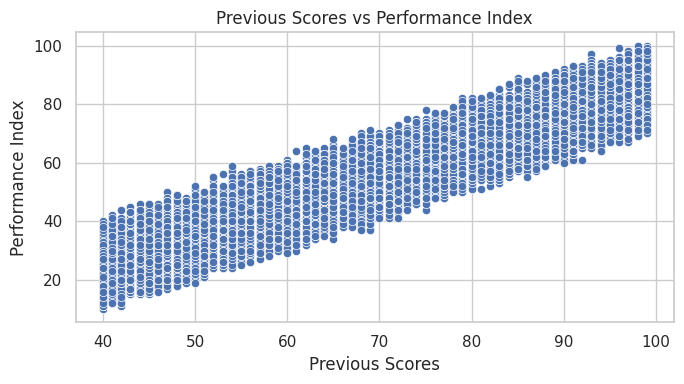

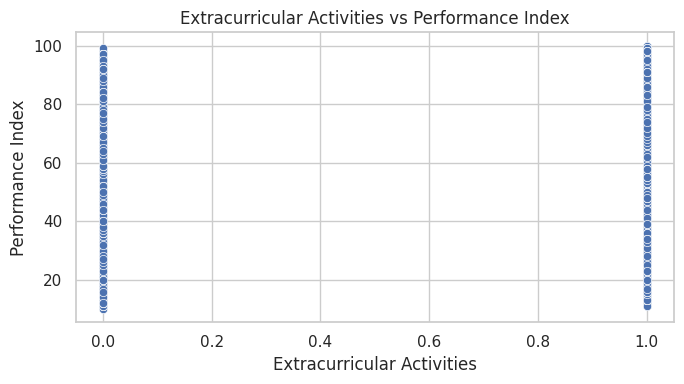

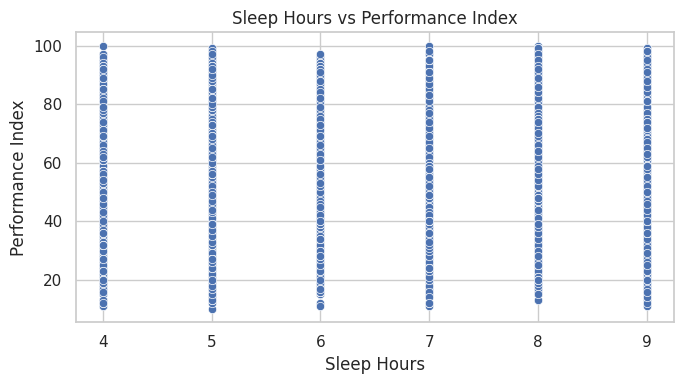

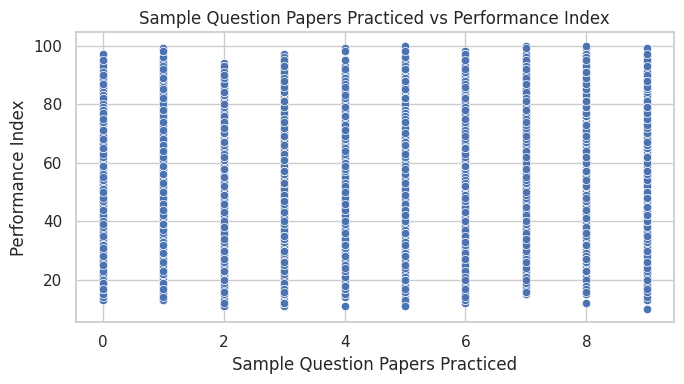

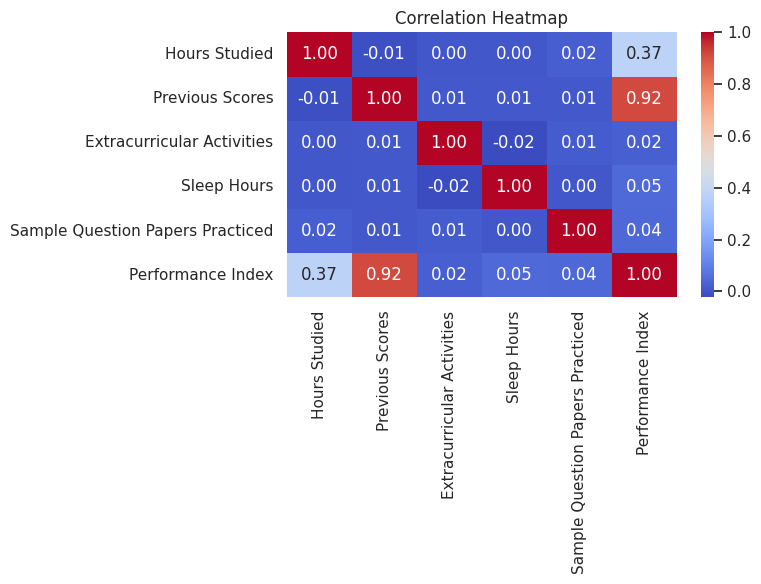

In [8]:
# Scatter plots
feature_columns = [col for col in df_encoded.columns if col != "Performance Index"]

for column in feature_columns:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df_encoded, x=column, y="Performance Index")
    plt.title(f"{column} vs Performance Index")
    plt.tight_layout()
    plt.show()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Correlation Analysis

In [9]:
# Compute correlation matrix
correlation_matrix = df_encoded.corr()
print("Correlation matrix:")
display(correlation_matrix)

Correlation matrix:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


## Feature Selection

In [10]:
# Define features (X) and target (y)
X = df_encoded.drop("Performance Index", axis=1)
y = df_encoded["Performance Index"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
display(X.head())
display(y.head())

Features (X) shape: (10000, 5)
Target (y) shape: (10000,)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0


## Train-Test Split

In [11]:
# Split dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7000, 5)
X_test shape: (3000, 5)
y_train shape: (7000,)
y_test shape: (3000,)


## Feature Scaling (If needed)

In [12]:
# Apply StandardScaler where needed
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (7000, 5)
Scaled testing data shape: (3000, 5)


## Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)

In [13]:
# Apply models and compare their performance
results = []

models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "train_data": X_train,
        "test_data": X_test
    },
    "SVR": {
        "model": SVR(),
        "train_data": X_train_scaled,
        "test_data": X_test_scaled
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "train_data": X_train,
        "test_data": X_test
    },
    "Random Forest": {
        "model": RandomForestRegressor(n_estimators=200, random_state=42),
        "train_data": X_train,
        "test_data": X_test
    },
    "KNN": {
        "model": KNeighborsRegressor(n_neighbors=5),
        "train_data": X_train_scaled,
        "test_data": X_test_scaled
    }
}

trained_models = {}
predictions = {}

for model_name, config in models.items():
    model = config["model"]
    X_train_used = config["train_data"]
    X_test_used = config["test_data"]

    train_start = time.time()
    model.fit(X_train_used, y_train)
    train_end = time.time()

    test_start = time.time()
    y_pred = model.predict(X_test_used)
    test_end = time.time()

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4),
        "Training Time": round(train_end - train_start, 6),
        "Testing Time": round(test_end - test_start, 6)
    })

    trained_models[model_name] = model
    predictions[model_name] = y_pred

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print("Model comparison results:")
display(results_df)

Model comparison results:


,Model,MAE,RMSE,R2 Score,Training Time,Testing Time
0,Linear Regression,1.6090,2.0166,0.9890,0.031745,0.001708
1,Random Forest,1.8296,2.2866,0.9859,3.896890,0.187796
2,SVR,1.8401,2.3845,0.9846,2.293856,0.914034
3,Decision Tree,2.3560,2.9643,0.9763,0.022084,0.002275
4,KNN,2.3719,2.9639,0.9763,0.007036,0.026077


### Answer the following

**1) Explain how Random Forest Regressor predicts a continuous value.**

A **Decision Tree Regressor** is a model that splits the data into smaller groups based on feature values. At each split, it tries to reduce error as much as possible, and at the final leaf node it predicts a numeric value, usually the average of the training samples present in that leaf.

**Bootstrapping** means creating many random samples from the training data **with replacement**. Because sampling is done with replacement, the same row can appear multiple times in one sample, while some rows may not appear at all. Each of these samples is used to train a separate decision tree.

In **Random Forest Regression**, multiple decision tree regressors are built instead of only one tree. Each tree is trained on a different bootstrapped dataset, and during splitting it also considers a random subset of features. This randomness helps reduce overfitting and makes the model more robust.

For a new input, the data point is passed through **all trees** in the forest. Every tree gives its own continuous prediction. The **final output** of the Random Forest Regressor is calculated by taking the **average of all tree predictions**.

### Answer the following

**2) Explain how KNN Regressor predicts output for a new data point.**

In **KNN Regressor**, **K** represents the number of nearest neighbors used for prediction. For example, if K = 5, the model will look at the 5 closest training points to the new data point.

The neighbors are selected by measuring the distance between the new point and all training points. Usually, Euclidean distance is used. The points with the smallest distances are considered the nearest neighbors. Because distance matters, KNN usually performs better when the features are scaled.

After selecting the nearest neighbors, the model takes their target values and computes the **average**. That average becomes the predicted output for the new data point. So, KNN Regressor predicts by using the values of nearby similar samples rather than building an explicit equation.

## Visualize Best Model

Best model based on R2 Score: Linear Regression


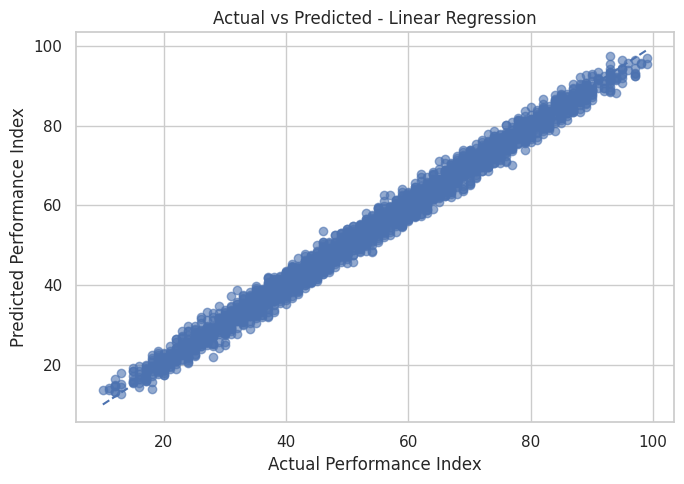

In [14]:
# Select best model based on R2 score and visualize it
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best model based on R2 Score:", best_model_name)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_predictions, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.tight_layout()
plt.show()

## Generate a Comparison Table of Regression Models

In [ ]:
# Generate a comparison table of regression models
comparison_table = results_df.copy()
display(comparison_table)

,Model,MAE,RMSE,R2 Score,Training Time,Testing Time
0,Linear Regression,1.6090,2.0166,0.9890,0.042218,0.006341
1,Random Forest,1.8296,2.2866,0.9859,2.922859,0.153845
2,SVR,1.8401,2.3845,0.9846,6.925298,1.823777
3,Decision Tree,2.3560,2.9643,0.9763,0.021982,0.002172
4,KNN,2.3719,2.9639,0.9763,0.006608,0.025889


Your output should look like this:

| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression | | | |||
| SVR | | | |||
| Decision Tree | | | |||
| Random Forest | | | |||
| KNN | | | |||

---